### 1. Реалізація функції harmonic_with_noise
**Завдання:** Реалізуйте функцію `harmonic_with_noise`, яка приймає амплітуду, частоту, фазу, середнє значення шуму, дисперсію шуму та флаг відображення шуму.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, CheckButtons
from scipy.signal import butter, filtfilt

t = np.linspace(0, 10, 1000)

base_noise = np.random.normal(0, 1, len(t))

def harmonic_with_noise(amplitude, frequency, phase, noise_mean, noise_covariance, show_noise=True):
    pure_harmonic = amplitude * np.sin(2 * np.pi * frequency * t + phase)
    
    if show_noise:
        current_noise = noise_mean + (noise_covariance * base_noise)
        noisy_harmonic = pure_harmonic + current_noise
    else:
        noisy_harmonic = pure_harmonic
        
    return pure_harmonic, noisy_harmonic

### 2. Фільтрація сигналу
**Завдання (п.7):** Отриману гармоніку відфільтруйте за допомогою фільтру на ваш вибір (наприклад, scipy.signal.iirfilter чи butter).

In [ ]:
def apply_filter(data, cutoff_freq, fs=100):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff_freq / nyquist
    
    if normal_cutoff <= 0 or normal_cutoff >= 1:
        return data
        
    b, a = butter(3, normal_cutoff, btype='low', analog=False)
    
    filtered_data = filtfilt(b, a, data)
    return filtered_data

### 3. Інтерактивний інтерфейс (Вікно, Слайдери, Чекбокси, Кнопки)
**Завдання (п.2-6, 8-10):** Створити головне вікно з полями для графіків, слайдерами для всіх параметрів, чекбоксом, кнопкою Reset. Оновлювати графік одразу після зміни параметрів.

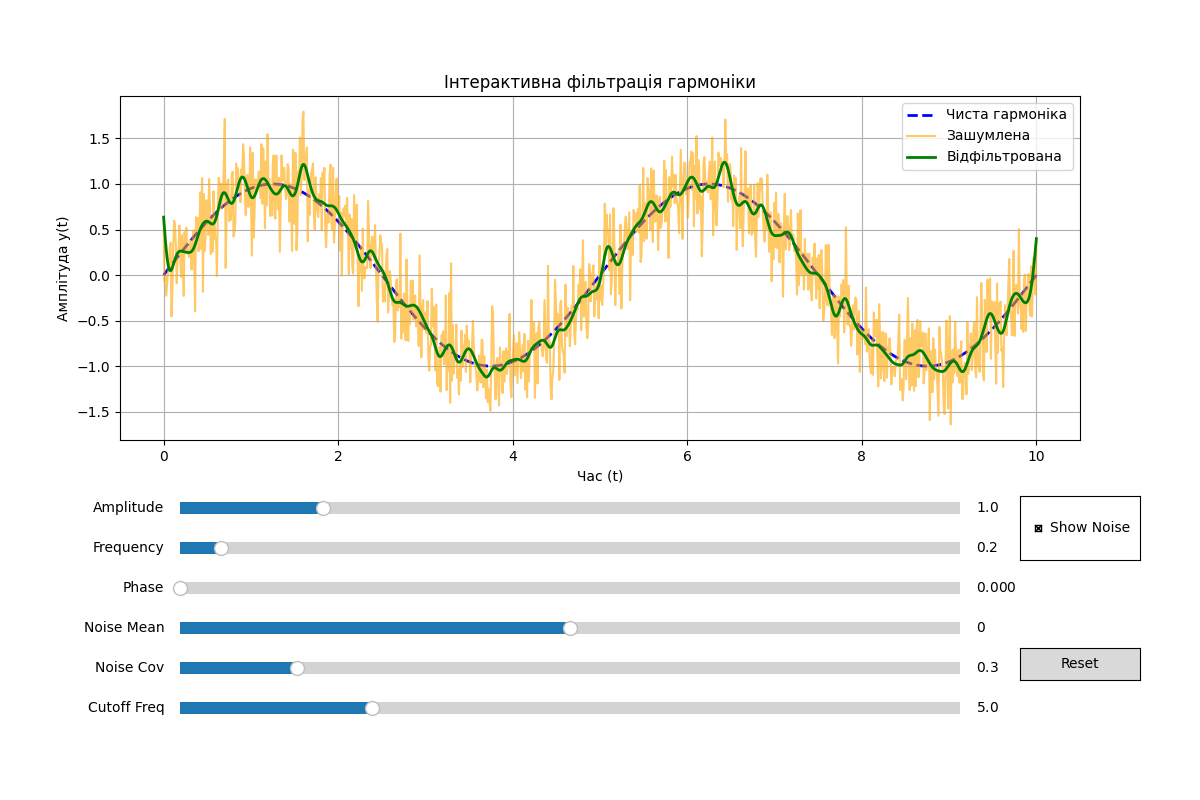

In [3]:
%matplotlib widget
init_amp = 1.0
init_freq = 0.2
init_phase = 0.0
init_n_mean = 0.0
init_n_cov = 0.3
init_cutoff = 5.0

fig, ax = plt.subplots(figsize=(12, 8))
plt.subplots_adjust(left=0.1, bottom=0.45) 

pure, noisy = harmonic_with_noise(init_amp, init_freq, init_phase, init_n_mean, init_n_cov, True)
filtered = apply_filter(noisy, init_cutoff)

line_pure, = ax.plot(t, pure, 'b--', label='Чиста гармоніка', linewidth=2)
line_noisy, = ax.plot(t, noisy, 'orange', label='Зашумлена', alpha=0.6)
line_filtered, = ax.plot(t, filtered, 'g', label='Відфільтрована', linewidth=2)

ax.set_title("Інтерактивна фільтрація гармоніки")
ax.set_xlabel("Час (t)")
ax.set_ylabel("Амплітуда y(t)")
ax.legend(loc='upper right')
ax.grid(True)

ax_amp   = plt.axes([0.15, 0.35, 0.65, 0.03])
ax_freq  = plt.axes([0.15, 0.30, 0.65, 0.03])
ax_phase = plt.axes([0.15, 0.25, 0.65, 0.03])
ax_n_mean = plt.axes([0.15, 0.20, 0.65, 0.03])
ax_n_cov  = plt.axes([0.15, 0.15, 0.65, 0.03])
ax_cutoff = plt.axes([0.15, 0.10, 0.65, 0.03])

s_amp   = Slider(ax_amp, 'Amplitude', 0.1, 5.0, valinit=init_amp)
s_freq  = Slider(ax_freq, 'Frequency', 0.1, 2.0, valinit=init_freq)
s_phase = Slider(ax_phase, 'Phase', 0.0, 2*np.pi, valinit=init_phase)
s_n_mean = Slider(ax_n_mean, 'Noise Mean', -2.0, 2.0, valinit=init_n_mean)
s_n_cov  = Slider(ax_n_cov, 'Noise Cov', 0.0, 2.0, valinit=init_n_cov)
s_cutoff = Slider(ax_cutoff, 'Cutoff Freq', 0.1, 20.0, valinit=init_cutoff)

ax_check = plt.axes([0.85, 0.3, 0.1, 0.08])
check_noise = CheckButtons(ax_check, ['Show Noise'], [True])

ax_reset = plt.axes([0.85, 0.15, 0.1, 0.04])
btn_reset = Button(ax_reset, 'Reset', hovercolor='0.975')

def update(val):
    show_n = check_noise.get_status()[0]
    
    p, n = harmonic_with_noise(
        s_amp.val, s_freq.val, s_phase.val, 
        s_n_mean.val, s_n_cov.val, show_n
    )
    
    f = apply_filter(n, s_cutoff.val)
    
    line_pure.set_ydata(p)
    line_noisy.set_ydata(n)
    line_filtered.set_ydata(f)
    
    line_noisy.set_visible(show_n)
    
    fig.canvas.draw_idle()

for s in [s_amp, s_freq, s_phase, s_n_mean, s_n_cov, s_cutoff]:
    s.on_changed(update)
check_noise.on_clicked(update)

def reset(event):
    for s in [s_amp, s_freq, s_phase, s_n_mean, s_n_cov, s_cutoff]:
        s.reset()
    if not check_noise.get_status()[0]:
        check_noise.set_active(0)
btn_reset.on_clicked(reset)

plt.show()